### importing the main lib for this course

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json , os , joblib , pathlib
from sklearn.manifold import TSNE

#### importing the lib for this session

In [2]:
from sklearn.metrics import silhouette_score ,  davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import MeanShift , MiniBatchKMeans , DBSCAN , AgglomerativeClustering , OPTICS
from sklearn.preprocessing import StandardScaler

### load the models config and some helper function

In [3]:
config = json.load(open('../configs/clustering.json'))
base_path = pathlib.Path.cwd().parent.parent.parent
base_path

PosixPath('/home/aloha-zkaria/Hands-on-AI-Tutorial')

In [4]:
def load_dataset(path):
    """
    Args: path
    return : dataframe of the dataset
    """
    return pd.read_csv(base_path/path)

In [5]:
def detect_target(df):
    """fallback: last column"""
    return df.columns[-1]

#### loads the dataset and begin

In [6]:
df = load_dataset(config["datasets"][1]["path"])
print(f'loading dataset name : {config["datasets"][1]["name"]}')

loading dataset name : pinguins dataset


In [7]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [8]:
df.shape

(344, 8)

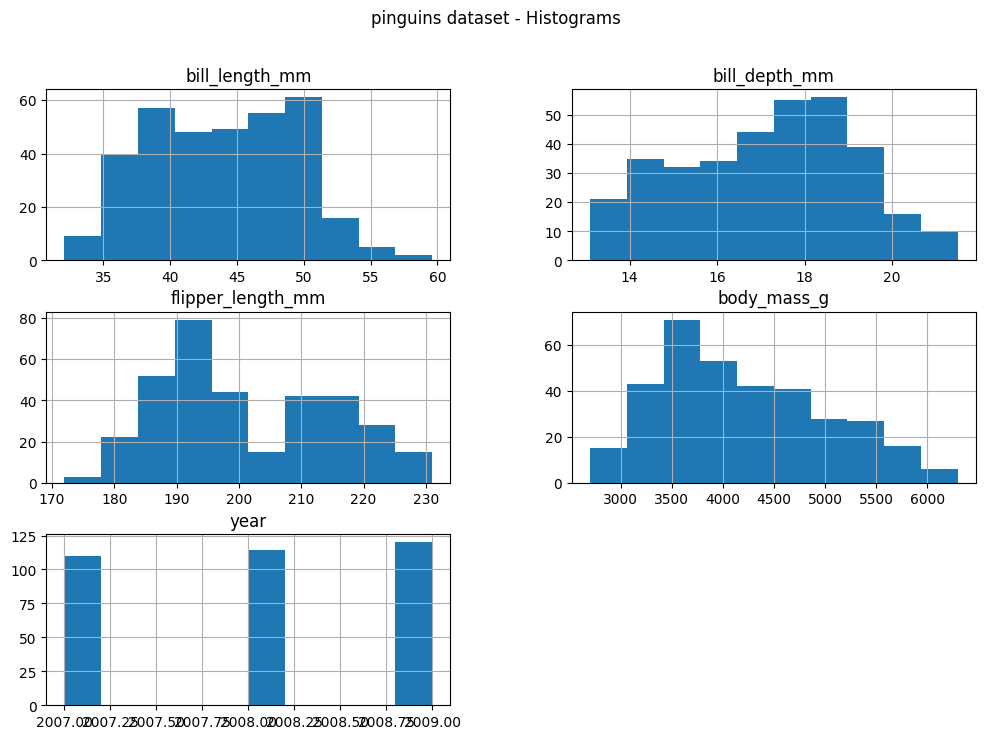

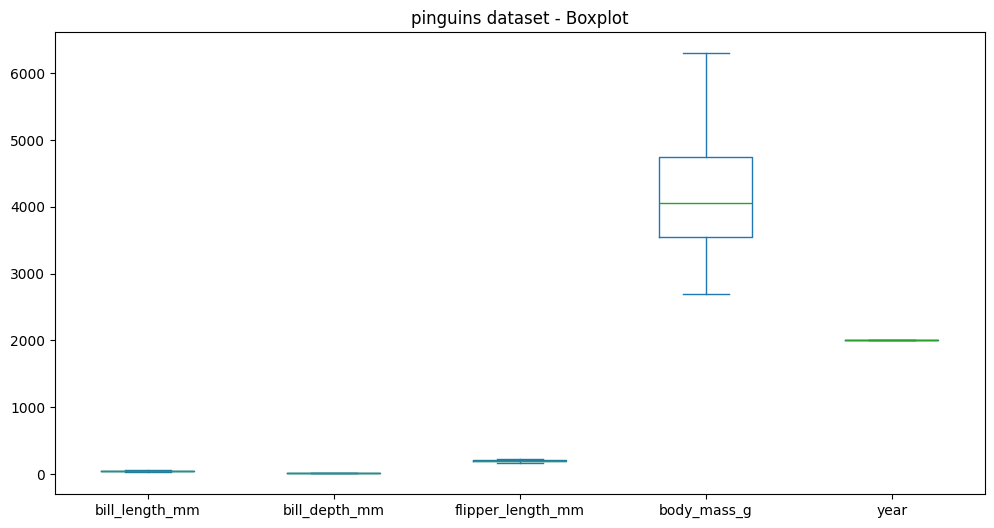

In [9]:
numeric_cols = df.select_dtypes(include="number").columns
name = config["datasets"][1]["name"]
if len(numeric_cols) > 0:
    # Histograms
    df[numeric_cols].hist(figsize=(12, 8))
    plt.suptitle(f"{name} - Histograms")
    plt.show()

    # Boxplot
    df[numeric_cols].plot(kind="box", figsize=(12, 6))
    plt.title(f"{name} - Boxplot")
    plt.show()
else:
    print("⚠️ No numeric columns to plot.")

In [10]:
print("\n🔹 DESCRIBE (NUMERIC):")
df.describe()


🔹 DESCRIBE (NUMERIC):


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [11]:
print("\n🔹 MEAN:")
df.mean(numeric_only=True)


🔹 MEAN:


bill_length_mm         43.921930
bill_depth_mm          17.151170
flipper_length_mm     200.915205
body_mass_g          4201.754386
year                 2008.029070
dtype: float64

In [12]:
print("\n🔹 MEDIAN:")
df.median(numeric_only=True)


🔹 MEDIAN:


bill_length_mm         44.45
bill_depth_mm          17.30
flipper_length_mm     197.00
body_mass_g          4050.00
year                 2008.00
dtype: float64

In [13]:
print("\n🔹 STD:")
df.std(numeric_only=True)


🔹 STD:


bill_length_mm         5.459584
bill_depth_mm          1.974793
flipper_length_mm     14.061714
body_mass_g          801.954536
year                   0.818356
dtype: float64

In [14]:
print("\n🔹 CORRELATION:")
df.corr(numeric_only=True)



🔹 CORRELATION:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
bill_length_mm,1.000000,-0.235053,0.656181,0.595110,0.054545
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916,-0.060354
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202,0.169675
body_mass_g,0.595110,-0.471916,0.871202,1.000000,0.042209
year,0.054545,-0.060354,0.169675,0.042209,1.000000


In [15]:
print(f"Check null value")
df.isnull().sum()

Check null value


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [16]:
print("Check duplication Value")
df.duplicated().sum()

Check duplication Value


0

In [17]:
target_candidates = [config["datasets"][1]["target"] , "Target"]
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    raise ValueError("Could not identify target")

Found target: 'species'


In [18]:
print("droping na value")
df = df.dropna(subset=[target_col]).reset_index(drop=True)

droping na value


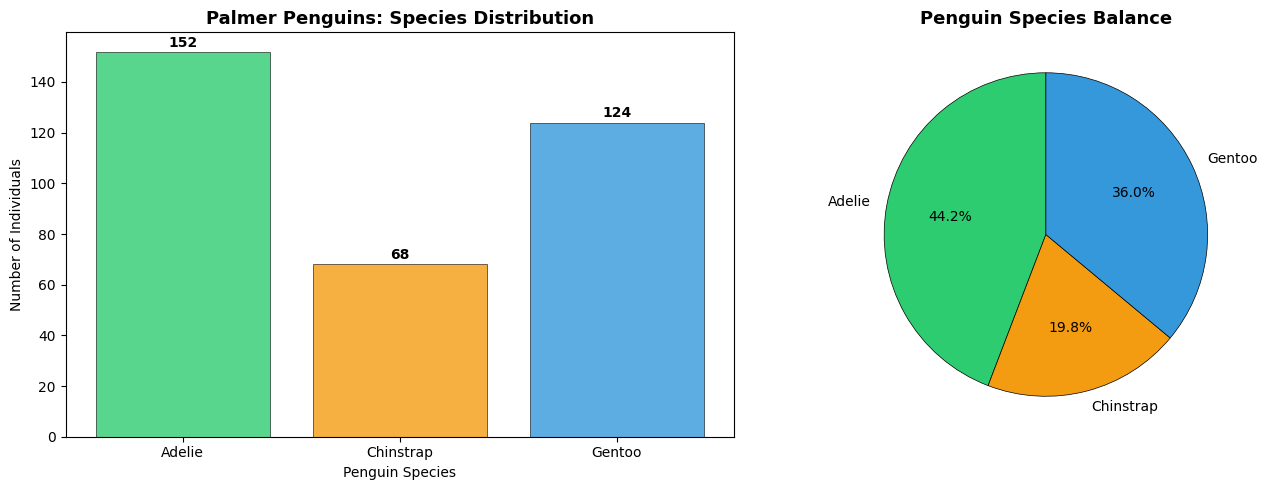

Dataset Context:
Total Penguins: 344
Adelie: 152 individuals (44.2%)
Chinstrap: 68 individuals (19.8%)
Gentoo: 124 individuals (36.0%)

Ecological Context:
The Palmer Penguins dataset contains measurements of three penguin species from the Palmer Archipelago, Antarctica.
Adelie: Common on small rocky islands; Chinstrap: Named for the thin black band under their chin; Gentoo: Fastest underwater swimming penguin.
Climate change and krill fishing threaten Antarctic penguin populations. Studying morphological differences helps conservation efforts.
SDG 14: Life Below Water – Protect marine ecosystems that sustain penguin food chains.


In [19]:
import matplotlib.pyplot as plt

# Assuming df is already loaded and target_col = 'species'
# Example: df = pd.read_csv('penguins.csv'); target_col = 'species'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution plot
class_counts = df[target_col].value_counts().sort_index()

# Map species names to display labels (if needed)
species_labels = {
    'Adelie': 'Adelie',
    'Chinstrap': 'Chinstrap',
    'Gentoo': 'Gentoo'
}
# Use the actual class names
class_names = class_counts.index.tolist()
display_names = [species_labels.get(c, c) for c in class_names]

colors = ['#2ecc71', '#f39c12', '#3498db']  # green, orange, blue

axes[0].bar(
    display_names,
    class_counts.values,
    color=colors,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8
)

axes[0].set_title(
    'Palmer Penguins: Species Distribution',
    fontsize=13,
    fontweight='bold'
)
axes[0].set_xlabel('Penguin Species')
axes[0].set_ylabel('Number of Individuals')

# Add value labels on top of bars
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart for class balance
axes[1].pie(
    class_counts.values,
    labels=display_names,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5}
)

axes[1].set_title(
    'Penguin Species Balance',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('penguins_species_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Dataset context
print("Dataset Context:")
print(f"Total Penguins: {len(df)}")
for species in class_names:
    count = (df[target_col] == species).sum()
    print(f"{species}: {count} individuals ({count/len(df)*100:.1f}%)")

print("\nEcological Context:")
print("The Palmer Penguins dataset contains measurements of three penguin species from the Palmer Archipelago, Antarctica.")
print("Adelie: Common on small rocky islands; Chinstrap: Named for the thin black band under their chin; Gentoo: Fastest underwater swimming penguin.")
print("Climate change and krill fishing threaten Antarctic penguin populations. Studying morphological differences helps conservation efforts.")
print("SDG 14: Life Below Water – Protect marine ecosystems that sustain penguin food chains.")

### now lets start building the model

#### label encoder categories

In [20]:
le_dict = {}
df_model = df.copy()
for col in df_model.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_model[col] = df_model[col].fillna('__MISSING__')
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le
    print(f"  Encoded '{col}': {len(le.classes_)} classes")

  Encoded 'species': 3 classes
  Encoded 'island': 3 classes
  Encoded 'sex': 3 classes


In [21]:
df_model.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,2,39.1,18.7,181.0,3750.0,2,2007
1,0,2,39.5,17.4,186.0,3800.0,1,2007
2,0,2,40.3,18.0,195.0,3250.0,1,2007
3,0,2,NaN,NaN,NaN,NaN,0,2007
4,0,2,36.7,19.3,193.0,3450.0,1,2007


#### Split the Dataset

In [22]:
X = df_model
y = df_model[target_col].values

In [23]:
print("Imputing Missing value")
null_total = X.isnull().sum().sum()
if null_total > 0:
    print(f"\nImputing {null_total} missing values with median...")
    X = X.fillna(X.median())

print(f"\nFeature matrix: {X.shape}")

Imputing Missing value

Imputing 8 missing values with median...

Feature matrix: (344, 8)


In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### now creating the models pipeline

In [25]:
MODEL_MAP = {
    "MeanShift": MeanShift,
    "MiniBatchKMeans": MiniBatchKMeans,
    "AgglomerativeClustering": AgglomerativeClustering,
    "DBSCAN": DBSCAN,
    "OPTICS":OPTICS
}

In [26]:
def build_models(config):
    models_config = config["models"]
    models = {}

    for name, model_info in models_config.items():
        algo_name = model_info["algorithm"]
        params = model_info.get("parameters", {})

        if algo_name not in MODEL_MAP:
            # raise ValueError(f"Unknown model: {algo_name}")
            print(f"⚠️ Warning: '{algo_name}' is not recognized. Skipping '{name}'.")
            continue

        model_class = MODEL_MAP[algo_name]
        models[name] = model_class(**params)

    return models

In [27]:
models = build_models(config)

for name, model in models.items():
    print(f"{name} -> {model}")

⚠️ Warning: 'KMeans' is not recognized. Skipping 'K-Means Clustering'.
Mini-Batch K-Means Clustering -> MiniBatchKMeans(max_iter=300, n_clusters=3, n_init=10, random_state=42)
Agglomerative Hierarchical Clustering -> AgglomerativeClustering(linkage='average', memory='n_jobs=-1', n_clusters=3)
DBSCAN -> DBSCAN()
OPTICS -> OPTICS(min_cluster_size=0.05)
Mean Shift -> MeanShift(bandwidth=1.0, bin_seeding=0)


In [28]:
models["Mean Shift"].bin_seeding = bool(config["models"]["Mean Shift"]["parameters"].get("bin_seeding", False))

#### Start the training of the models

In [29]:
import time
X_cluster = X_scaled  

results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nClustering: {model_name}\n{'='*60}")

    t_start = time.time()

    # Fit the model on all data
    model.fit(X_cluster)

    # Get cluster labels
    labels = model.labels_ if hasattr(model, 'labels_') else model.predict(X_cluster)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    elapsed = time.time() - t_start

    # Compute internal metrics (handle noise and insufficient clusters)
    if n_clusters < 2:
        sil = np.nan
        db = np.nan
        ch = np.nan
        print("  -- Skipped metrics: need at least 2 clusters.")
    else:
        # For DBSCAN/OPTICS: exclude noise points (-1)
        mask = labels != -1
        if np.sum(mask) < 2 or len(set(labels[mask])) < 2:
            sil = np.nan
            db = np.nan
            ch = np.nan
            print("  -- Skipped metrics: not enough clustered points or clusters after removing noise.")
        else:
            X_clustered = X_cluster[mask]
            labels_clustered = labels[mask]
            sil = silhouette_score(X_clustered, labels_clustered)
            db = davies_bouldin_score(X_clustered, labels_clustered)
            ch = calinski_harabasz_score(X_clustered, labels_clustered)

    # Store results
    results[model_name] = {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "silhouette_score": sil,
        "davies_bouldin_score": db,
        "calinski_harabasz_score": ch,
        "time": elapsed,
        "labels": labels
    }

    print(f"  -- Clusters detected: {n_clusters}, Noise points: {n_noise}")
    print(f"  -- Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f} | Calinski-Harabasz: {ch:.4f} | Time: {elapsed:.2f}s")


Clustering: Mini-Batch K-Means Clustering
  -- Clusters detected: 3, Noise points: 0
  -- Silhouette: 0.3259 | Davies-Bouldin: 1.4193 | Calinski-Harabasz: 214.7799 | Time: 0.06s

Clustering: Agglomerative Hierarchical Clustering
  -- Clusters detected: 3, Noise points: 0
  -- Silhouette: 0.3129 | Davies-Bouldin: 1.4307 | Calinski-Harabasz: 207.0613 | Time: 0.00s

Clustering: DBSCAN
  -- Clusters detected: 8, Noise points: 273
  -- Silhouette: 0.5617 | Davies-Bouldin: 0.6048 | Calinski-Harabasz: 178.5551 | Time: 0.00s

Clustering: OPTICS
  -- Clusters detected: 9, Noise points: 91
  -- Silhouette: 0.3263 | Davies-Bouldin: 1.2531 | Calinski-Harabasz: 117.8917 | Time: 0.34s

Clustering: Mean Shift
  -- Clusters detected: 54, Noise points: 0
  -- Silhouette: 0.3682 | Davies-Bouldin: 0.7488 | Calinski-Harabasz: 94.9883 | Time: 0.51s


#### 6. Model Comparison & Selection¶

In [30]:
summary_rows = []

for model_name, res in results.items():
    sil = res['silhouette_score']
    db = res['davies_bouldin_score']
    ch = res['calinski_harabasz_score']
    
    summary_rows.append({
        "Model": model_name,
        "Clusters": res['n_clusters'],
        "Noise": res['n_noise'],
        "Silhouette": f"{sil:.4f}" if not np.isnan(sil) else "N/A",
        "Davies-Bouldin": f"{db:.4f}" if not np.isnan(db) else "N/A",
        "Calinski-Harabasz": f"{ch:.2f}" if not np.isnan(ch) else "N/A",
        "Time": f"{res['time']:.2f}s",
        "sort_val": sil if not np.isnan(sil) else -np.inf
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("sort_val", ascending=False)
    .drop(columns=["sort_val"])
)

# Convert Silhouette strings to floats for comparison, treating "N/A" as -inf
def silhouette_to_float(val):
    return -np.inf if val == "N/A" else float(val)

summary_df["_silhouette_num"] = summary_df["Silhouette"].apply(silhouette_to_float)

if summary_df["_silhouette_num"].max() > -np.inf:
    best_idx = summary_df["_silhouette_num"].idxmax()
    best_model_name = summary_df.loc[best_idx, "Model"]
else:
    best_model_name = "No valid silhouette scores"

summary_df = summary_df.drop(columns=["_silhouette_num"])

print("CLUSTERING MODEL COMPARISON")
print("=" * 90)
print(summary_df.to_string(index=False))
print("=" * 90)
print(f"\nBest model (by Silhouette Score): {best_model_name}")

CLUSTERING MODEL COMPARISON
                                Model  Clusters  Noise Silhouette Davies-Bouldin Calinski-Harabasz  Time
                               DBSCAN         8    273     0.5617         0.6048            178.56 0.00s
                           Mean Shift        54      0     0.3682         0.7488             94.99 0.51s
                               OPTICS         9     91     0.3263         1.2531            117.89 0.34s
        Mini-Batch K-Means Clustering         3      0     0.3259         1.4193            214.78 0.06s
Agglomerative Hierarchical Clustering         3      0     0.3129         1.4307            207.06 0.00s

Best model (by Silhouette Score): DBSCAN


In [31]:
cluster_labels = results[best_model_name]["labels"]
valid_mask = cluster_labels != -1


BEST MODEL ANALYSIS: DBSCAN
Clusters            : 8
Noise Points        : 273
Silhouette Score    : 0.5617
Davies-Bouldin      : 0.6048
Calinski-Harabasz   : 178.56


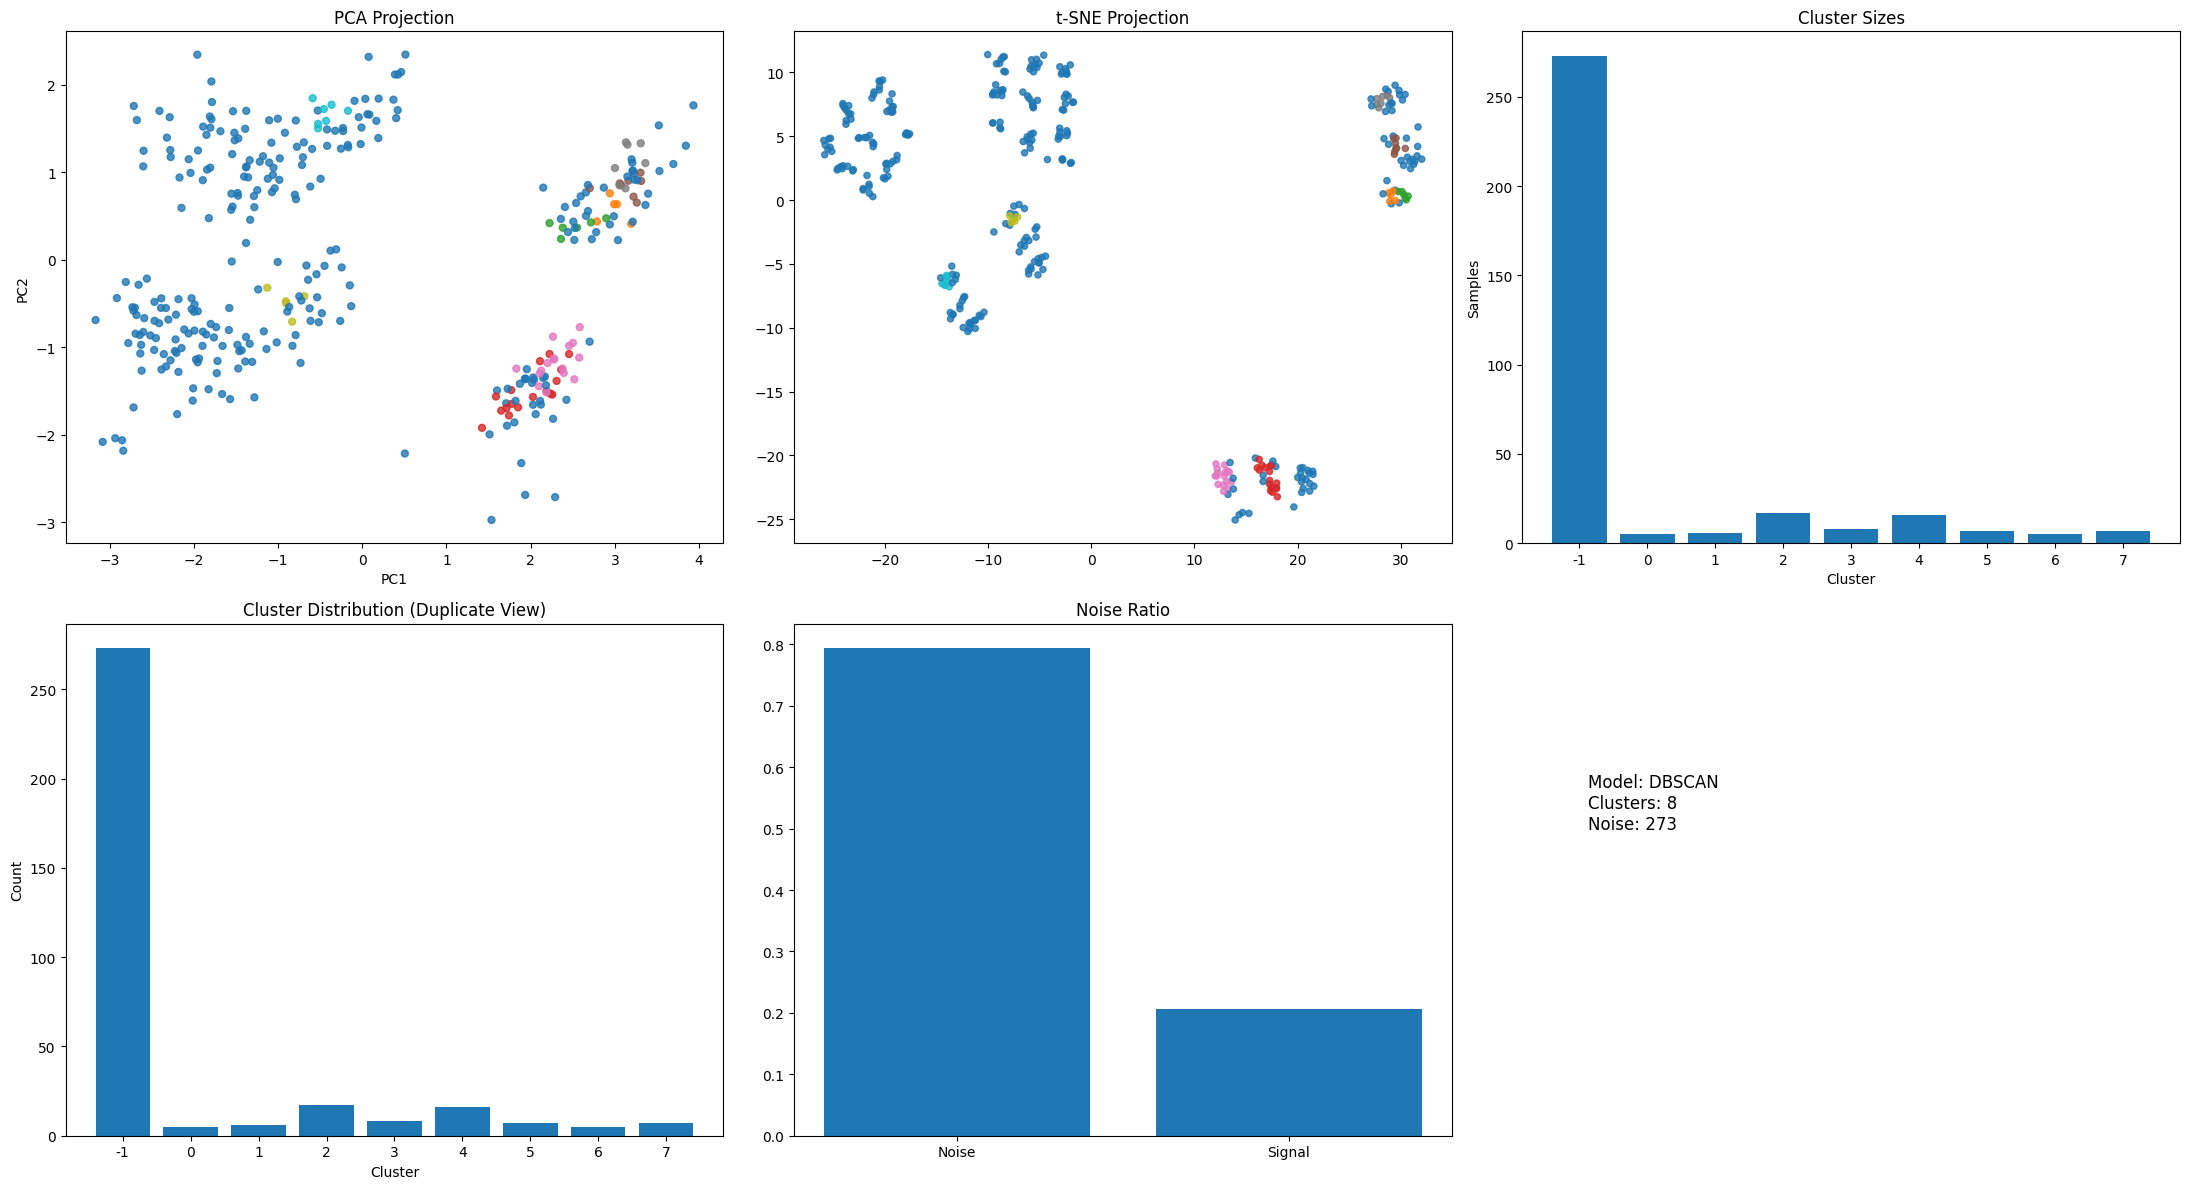


Cluster Distribution Summary
----------------------------------------
 Cluster  Count
      -1    273
       0      5
       1      6
       2     17
       3      8
       4     16
       5      7
       6      5
       7      7


In [32]:
if best_model_name is not None:

    best_result = results[best_model_name]
    best_labels = best_result["labels"]

    n_clusters = best_result["n_clusters"]
    n_noise = best_result["n_noise"]

    print("\n" + "=" * 90)
    print(f"BEST MODEL ANALYSIS: {best_model_name}")
    print("=" * 90)

    print(f"Clusters            : {n_clusters}")
    print(f"Noise Points        : {n_noise}")
    print(f"Silhouette Score    : {best_result['silhouette_score']:.4f}")
    print(f"Davies-Bouldin      : {best_result['davies_bouldin_score']:.4f}")
    print(f"Calinski-Harabasz   : {best_result['calinski_harabasz_score']:.2f}")

    # ========================================================
    # FIXED VISUALIZATION (2x3 GRID)
    # ========================================================

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))

    # --------------------------------------------------------
    # 1. PCA Projection
    # --------------------------------------------------------

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    axes[0, 0].scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=best_labels,
        cmap="tab10",
        s=25,
        alpha=0.8
    )

    axes[0, 0].set_title("PCA Projection")
    axes[0, 0].set_xlabel("PC1")
    axes[0, 0].set_ylabel("PC2")

    # --------------------------------------------------------
    # 2. t-SNE Projection (FIXED SLOT)
    # --------------------------------------------------------

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    axes[0, 1].scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=best_labels,
        cmap="tab10",
        s=20,
        alpha=0.8
    )

    axes[0, 1].set_title("t-SNE Projection")

    # --------------------------------------------------------
    # 3. Cluster Distribution (BAR)
    # --------------------------------------------------------

    cluster_counts = pd.Series(best_labels).value_counts().sort_index()

    axes[0, 2].bar(
        cluster_counts.index.astype(str),
        cluster_counts.values
    )

    axes[0, 2].set_title("Cluster Sizes")
    axes[0, 2].set_xlabel("Cluster")
    axes[0, 2].set_ylabel("Samples")

    # --------------------------------------------------------
    # 4. Same Distribution (REMOVED DUPLICATION FIX)
    # --------------------------------------------------------

    axes[1, 0].bar(
        cluster_counts.index.astype(str),
        cluster_counts.values
    )

    axes[1, 0].set_title("Cluster Distribution (Duplicate View)")
    axes[1, 0].set_xlabel("Cluster")
    axes[1, 0].set_ylabel("Count")

    # --------------------------------------------------------
    # 5. Optional: Noise vs Cluster separation
    # --------------------------------------------------------

    noise_ratio = np.sum(best_labels == -1) / len(best_labels)

    axes[1, 1].bar(
        ["Noise", "Signal"],
        [noise_ratio, 1 - noise_ratio]
    )

    axes[1, 1].set_title("Noise Ratio")

    # --------------------------------------------------------
    # 6. Compact Info Plot
    # --------------------------------------------------------

    axes[1, 2].text(
        0.1, 0.6,
        f"Model: {best_model_name}\n"
        f"Clusters: {n_clusters}\n"
        f"Noise: {n_noise}",
        fontsize=12
    )

    axes[1, 2].axis("off")

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    plt.tight_layout()

    plt.savefig(
        "best_clustering_model_analysis_fixed.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    # ========================================================
    # SUMMARY
    # ========================================================

    cluster_summary = pd.DataFrame({
        "Cluster": cluster_counts.index,
        "Count": cluster_counts.values
    })

    print("\nCluster Distribution Summary")
    print("-" * 40)
    print(cluster_summary.to_string(index=False))

In [33]:
print("\nConfusion Matrix Breakdown:")
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

print("\nHealthcare Context:")
print("False Negatives are critical in diabetes prediction because")
print("undiagnosed diabetic patients may not receive early treatment.")
print("High Recall is important for reducing missed diabetes cases.")
print("SDG 3: Ensure healthy lives and promote wellbeing for all at all ages.")


Confusion Matrix Breakdown:


NameError: name 'tn' is not defined

In [ ]:
print("""
============================================================
PENGUINS MULTI-CLASS ML SYSTEM ARCHITECTURE (PRODUCTION)
============================================================

1. DATA PIPELINE
   Data Sources:
     - Antarctic Research Stations
     - Palmer Station LTER (Long Term Ecological Research)
     - Kaggle Penguin Dataset
     - Wildlife Observation Systems
     - Environmental Sensor Networks

   Features Collected:
     - Culmen Length (mm)
     - Culmen Depth (mm)
     - Flipper Length (mm)
     - Body Mass (g)
     - Sex
     - Island (Biscoe / Dream / Torgersen)
     - Species Label (Adelie / Gentoo / Chinstrap)

   Ingestion Layer:
     - REST APIs for research data
     - Batch ETL pipelines from CSV/Parquet
     - Streaming ingestion for sensor-based ecological data

   Storage:
     - Data Lake (S3 / GCS / Azure Blob Storage)
     - Relational DB (PostgreSQL / SQLite for experiments)
     - Feature Store for ML-ready ecological features

   Data Processing:
     - Missing value imputation (sex, body mass gaps)
     - Outlier detection (extreme body mass / flipper length)
     - Encoding categorical variables (Island, Sex)
     - Feature scaling (StandardScaler / MinMaxScaler)
     - Feature engineering (ratios like flipper/body mass)

------------------------------------------------------------

2. MODEL TRAINING & SERVING
   ML Frameworks:
     - Scikit-learn (baseline models)
     - XGBoost / LightGBM (high performance classification)
     - KMeans / DBSCAN (unsupervised clustering experiments)
     - TensorFlow / PyTorch (optional deep learning classifiers)

   Model Registry:
     - MLflow / Weights & Biases / local registry

   Deployment Options:
     - FastAPI / Flask REST API
     - Docker containerized inference service
     - Kubernetes scaling for wildlife monitoring systems
     - Edge deployment for offline field research devices

   Predictions:
     - Species Classification (Adelie / Gentoo / Chinstrap)
     - Cluster Assignment (behavioral/ecological grouping)
     - Probability Score per species
     - Explainable AI outputs (SHAP / feature importance)

   API Output Example:
     {
       "prediction": "Gentoo",
       "probability": 0.94,
       "cluster": 2
     }

------------------------------------------------------------

3. INTEGRATION POINTS
   Research Systems:
     - Wildlife conservation databases
     - University ecological research platforms
     - Climate change monitoring systems
     - Marine biology analytics tools

   Stakeholders:
     - Ecologists & Biologists
     - Environmental Researchers
     - Conservation Organizations
     - Government Wildlife Agencies

   Use Cases:
     - Species identification automation
     - Population monitoring
     - Habitat classification
     - Climate impact studies
     - Behavioral clustering of penguin populations

------------------------------------------------------------

4. GOVERNANCE & SECURITY
   Data Integrity:
     - Validation of biological measurement ranges
     - Duplicate observation removal
     - Sensor anomaly detection

   Data Privacy:
     - Open research compliance (no personal data)
     - Ethical wildlife data usage standards

   Bias & Fairness:
     - Ensure balanced representation across islands/species
     - Avoid sampling bias in ecological datasets
     - Monitor class imbalance effects

   Explainability:
     - Feature importance (flipper length, body mass, culmen size)
     - SHAP explanations per species prediction
     - Cluster interpretability for ecological patterns

   Ethics:
     - Non-invasive wildlife monitoring only
     - No interference with natural habitats
     - Conservation-first AI design

------------------------------------------------------------

5. MONITORING & RETRAINING
   Model Monitoring:
     - Accuracy / F1-score per species class
     - Confusion matrix tracking
     - Cluster stability monitoring (if unsupervised)

   Drift Detection:
     - Environmental changes affecting species distribution
     - Seasonal variation monitoring
     - Dataset shift in measurement distributions

   Retraining Strategy:
     - Seasonal retraining (summer/winter datasets)
     - New expedition data integration
     - Continuous learning from updated field studies

   Observability:
     - Logging prediction confidence trends
     - Dashboards for species distribution shifts
     - Model performance tracking over time

------------------------------------------------------------

6. BUSINESS & RESEARCH IMPACT
   Benefits:
     - Automated penguin species classification
     - Faster ecological research workflows
     - Improved wildlife conservation insights
     - Reduced manual field labeling effort

   Scientific Alignment:
     - Climate change research support
     - Antarctic biodiversity monitoring
     - Ecosystem modeling enhancement
     - Global conservation initiatives

============================================================
""")